In [1]:
%%html
<style>
.rendered_html p {
    font-size: 17px;
    font-family: "Times New Roman";
    text-align:justify}
</style>


# Decision Trees and Random Forests in Python

This is the code for the lecture video which goes over tree methods in Python. Reference the video lecture for the full explanation of the code!

I also refer you to a [blog post](https://medium.com/@josemarcialportilla/enchanted-random-forest-b08d418cb411#.hh7n1co54) explaining the general logic of decision trees and random forests which you can check out. 

## Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#%matplotlib inline

## Get the Data
Reference: https://www.kaggle.com/abbasit/kyphosis-dataset

### INPUTS:

- **Age**: in months
- **Number**: the number of vertebrae involved
- **Start**: the number of the first (topmost) vertebra operated on.

### OUTPUTS:

- **Kyphosis**: a factor with levels absent present indicating if a kyphosis (a type of deformation) was present after the operation.

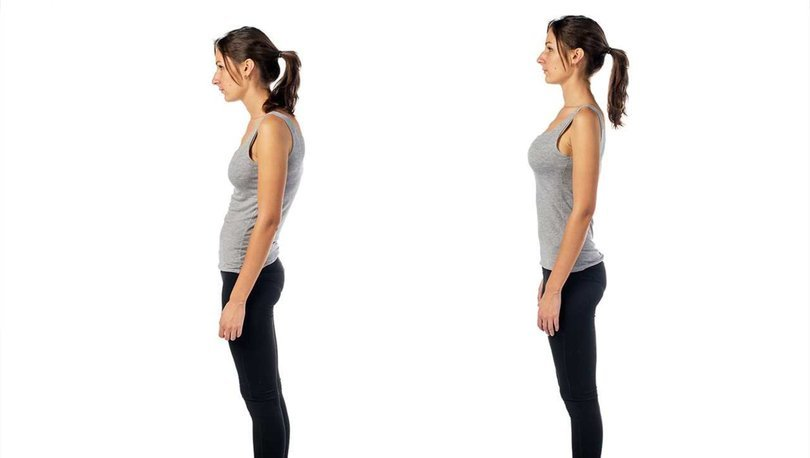

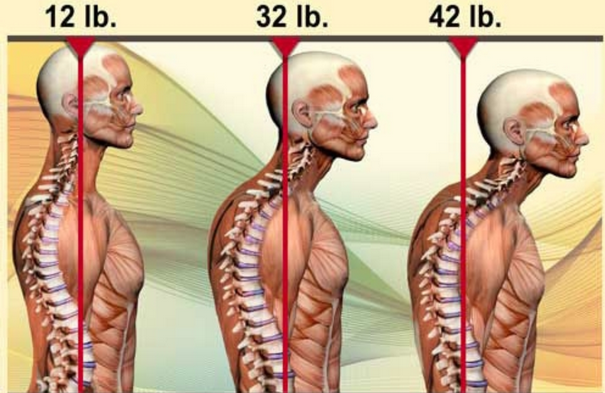

In [3]:
df = pd.read_csv(r'./kyphosis.csv', sep=',', engine='c', encoding = 'utf8')

In [4]:
df

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [5]:
url = 'https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/rpart/kyphosis.csv'
df=pd.read_csv(url, index_col=0)
df

,Kyphosis,Age,Number,Start
rownames,,,,
1,absent,71,3,5
2,absent,158,3,14
3,present,128,4,5
4,absent,2,5,1
5,absent,1,4,15
...,...,...,...,...
77,present,157,3,13
78,absent,26,7,13
79,absent,120,2,13


## EDA

We'll just check out a simple pairplot for this small dataset.

#### Many classification algorithms work better on numbers (continuous or discrete) than the text format of categorial data.

### We covert the outcomes: "absent" = 0 and "present" = 1 using scikit learn.preprocessing.LabelEncoder


In [6]:
df

,Kyphosis,Age,Number,Start
rownames,,,,
1,absent,71,3,5
2,absent,158,3,14
3,present,128,4,5
4,absent,2,5,1
5,absent,1,4,15
...,...,...,...,...
77,present,157,3,13
78,absent,26,7,13
79,absent,120,2,13


In [7]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
LabelEncoder_y = LabelEncoder()
df['Kyphosis'] = LabelEncoder_y.fit_transform(df['Kyphosis'])

### <font color='0000ff'>Or one can do this conversion manually</font>

In [8]:
# Or one can do this manually
mapping = {'absent': 0, 'present': 1}
df.replace({'Kyphosis': mapping}, inplace=True)

,Kyphosis,Age,Number,Start
rownames,,,,
1,0,71,3,5
2,0,158,3,14
3,1,128,4,5
4,0,2,5,1
5,0,1,4,15
...,...,...,...,...
77,1,157,3,13
78,0,26,7,13
79,0,120,2,13


In [9]:
df

,Kyphosis,Age,Number,Start
rownames,,,,
1,0,71,3,5
2,0,158,3,14
3,1,128,4,5
4,0,2,5,1
5,0,1,4,15
...,...,...,...,...
77,1,157,3,13
78,0,26,7,13
79,0,120,2,13


In [10]:
df['Kyphosis']

rownames
1     0
2     0
3     1
4     0
5     0
     ..
77    1
78    0
79    0
80    1
81    0
Name: Kyphosis, Length: 81, dtype: int64

<Axes: xlabel='Kyphosis', ylabel='count'>

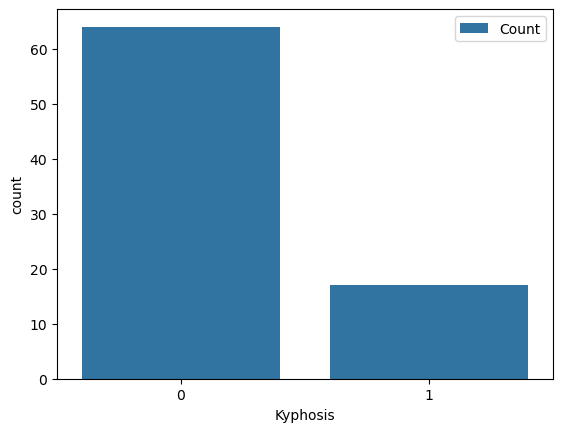

In [11]:
sns.countplot(x=df["Kyphosis"], label = "Count") 
# Or
# sns.countplot(data=df, x="Kyphosis", label = "Count") 


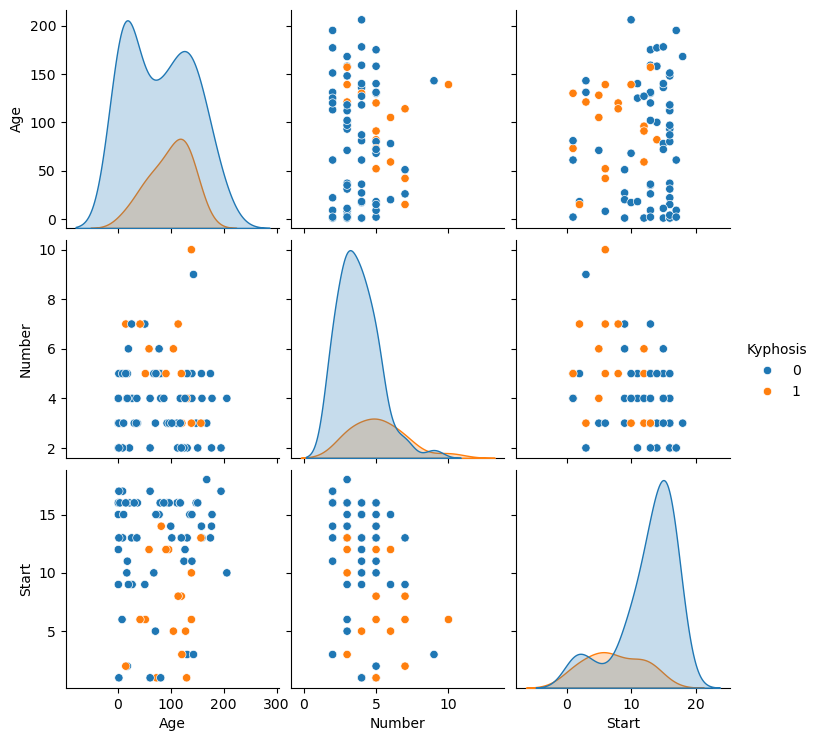

In [12]:
sns.pairplot(df,hue='Kyphosis',palette='tab10')

<Axes: >

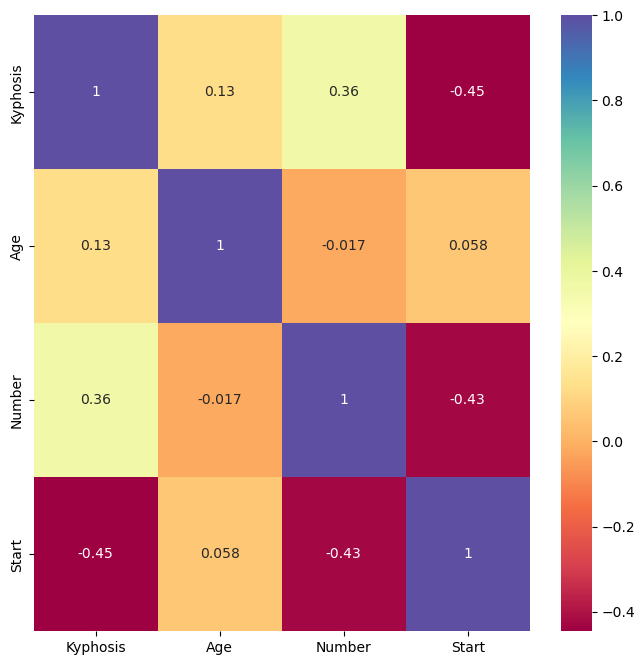

In [13]:
plt.figure(figsize=(8,8)) 
sns.heatmap(df.corr(), annot=True, cmap="Spectral") 

## Train Test Split

Let's split up the data into a training set and a test set!

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = df.drop('Kyphosis',axis=1)
y = df['Kyphosis']

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

## Decision Trees

We'll start just by training a single decision tree.

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
dtree = DecisionTreeClassifier(max_depth=4, max_features="sqrt")

In [19]:
dtree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

## Prediction and Evaluation 

Let's evaluate our decision tree.

In [20]:
predictions = dtree.predict(X_test)

In [21]:
from sklearn.metrics import classification_report,confusion_matrix


In [22]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       0.00      0.00      0.00         3

    accuracy                           0.82        17
   macro avg       0.41      0.50      0.45        17
weighted avg       0.68      0.82      0.74        17



C:\Users\chw\anaconda3\envs\IMSE685\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\chw\anaconda3\envs\IMSE685\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\chw\anaconda3\envs\IMSE685\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

[[14  0]
 [ 3  0]]


<Axes: >

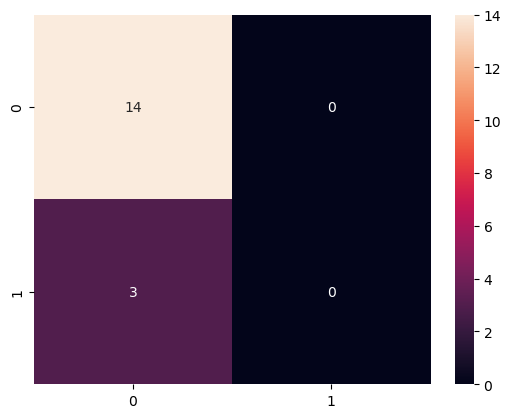

In [23]:
dt_cm = confusion_matrix(y_test,predictions)
print(dt_cm)
sns.heatmap(dt_cm, annot=True)

[Text(0.421875, 0.9, 'x[0] <= 39.5\ngini = 0.342\nsamples = 64\nvalue = [50, 14]'),
 Text(0.1875, 0.7, 'x[2] <= 4.0\ngini = 0.095\nsamples = 20\nvalue = [19, 1]'),
 Text(0.3046875, 0.8, 'True  '),
 Text(0.125, 0.5, 'x[1] <= 6.0\ngini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.0625, 0.3, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.1875, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 17\nvalue = [17, 0]'),
 Text(0.65625, 0.7, 'x[0] <= 139.5\ngini = 0.416\nsamples = 44\nvalue = [31, 13]'),
 Text(0.5390625, 0.8, '  False'),
 Text(0.4375, 0.5, 'x[1] <= 5.5\ngini = 0.469\nsamples = 32\nvalue = [20, 12]'),
 Text(0.3125, 0.3, 'x[1] <= 2.5\ngini = 0.403\nsamples = 25\nvalue = [18.0, 7.0]'),
 Text(0.25, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.375, 0.1, 'gini = 0.434\nsamples = 22\nvalue = [15.0, 7.0]'),
 Text(0.5625, 0.3, 'x[0] <= 91.5\ngini = 0.408\nsamples = 7\nvalue = [2, 5]'),
 Text(0.5, 0.1, 'gini = 0.5\nsamples = 4\nva

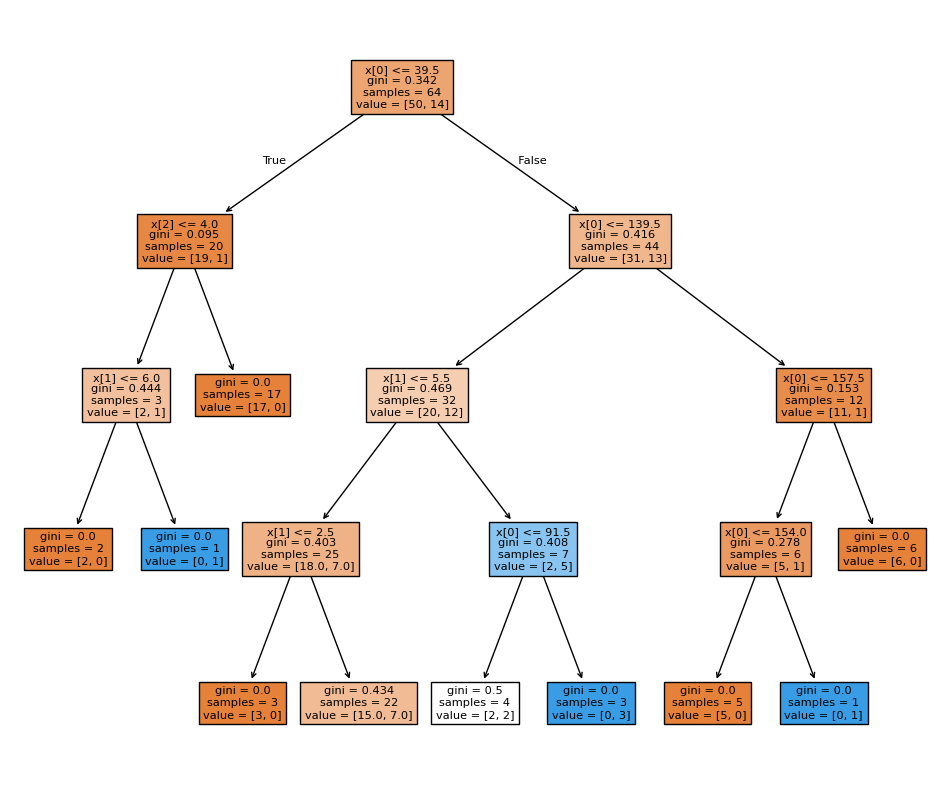

In [24]:
from sklearn import tree
plt.figure(figsize=(12,10))
tree.plot_tree(dtree, filled=True) 

## Tree Visualization

You'll need to download and install Graphvis software from https://www.graphviz.org/download/

Scikit learn actually has some built-in visualization capabilities for decision trees, you won't use this often and it requires you to install the pydot library, but here is an example of what it looks like and the code to execute this:

In [25]:
#!pip install six
#!conda install pydot -y


In [26]:
from IPython.display import Image  
#from sklearn.externals.six import StringIO # For Scikit Learn 0.22 and before  
from six import StringIO  
#from sklearn.tree import export_graphviz
#import pydot 

features = list(df.columns[1:])
features

['Age', 'Number', 'Start']

In [27]:
#dot_data = StringIO()  
#export_graphviz(dtree, out_file=dot_data,feature_names=features,filled=True,rounded=True)

#graph = pydot.graph_from_dot_data(dot_data.getvalue())  
#Image(graph[0].create_png())  

## Gini Index

**Gini Index**, also known as **Gini impurity**, **calculates the amount of probability of a specific feature that is classified incorrectly when selected randomly**. If all the elements are linked with a single class then it can be called pure.
Let’s perceive the criterion of the Gini Index, like the properties of entropy, the Gini index varies between values 0 and 1, where 0 expresses the purity of classification, i.e. All the elements belong to a specified class or only one class exists there. And 1 indicates the random distribution of elements across various classes. The value of 0.5 of the Gini Index shows an equal distribution of elements over some classes.

While designing the decision tree, the features possessing the least value of the Gini Index would get preferred. You can learn another tree-based algorithm(Random Forest).

The Gini Index is determined by deducting the sum of squared of probabilities of each class from one, mathematically, Gini Index can be expressed as:

$$
\text{Gini Index} = 1 - \sum_{i=1}^{n}(P_i)^2
$$
where $P_i$ denotes the probability of an element being classified for a distinct class $i$.

## Random Forests

Now let's compare the decision tree model to a random forest ```sklearn.RandomForestClassifier```.

In [28]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
rfc_pred = rfc.predict(X_test)

[[13  1]
 [ 2  1]]


<Axes: >

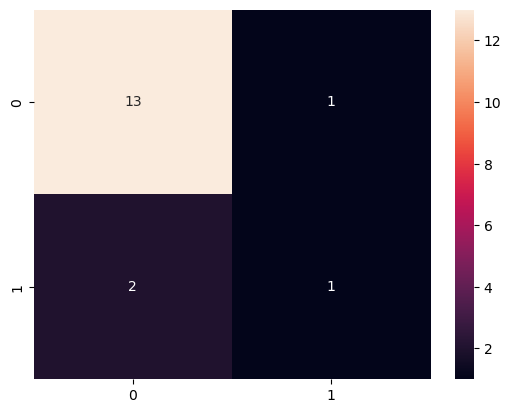

In [30]:
rfc_cm = confusion_matrix(y_test,rfc_pred)
print(rfc_cm)
sns.heatmap(rfc_cm, annot=True)

In [31]:
print(classification_report(y_test,rfc_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90        14
           1       0.50      0.33      0.40         3

    accuracy                           0.82        17
   macro avg       0.68      0.63      0.65        17
weighted avg       0.80      0.82      0.81        17



Defining an XGBoost model
Now that our data is all loaded up, we can define the parameters of our gradient boosting ensemble. We’ve set up some of the most important ones below to get us started. For more complicated tasks and models, the full list of possible parameters is available on the official [XGBoost website](https://xgboost.readthedocs.io/en/latest/parameter.html).

# Gradient Boosted Decision Tree (XGBoost)

XGBoost is an open source library providing a high-performance implementation of gradient boosted decision trees. An underlying C++ codebase combined with a Python interface sitting on top makes for an extremely powerful yet easy to implement package.
The performance of XGBoost is no joke — it’s become the go-to library for winning many Kaggle competitions. Its gradient boosting implementation is second to none and there’s only more to come as the library continues to garner praise.
In this post we’re going to go through the basics of the XGBoost library. We’ll start with a practical explanation of how gradient boosting actually works and then go through a Python example of how XGBoost makes it oh-so quick and easy to do it.

## Boosting Trees

With a regular machine learning model, like a decision tree, we’d simply train a single model on our dataset and use that for prediction. We might play around with the parameters for a bit or augment the data, but in the end we are still using a single model. Even if we build an ensemble, all of the models are trained and applied to our data separately.

**Boosting, on the other hand**, takes a more iterative approach. It’s still technically an ensemble technique in that many models are combined together to perform the final one, but takes a more clever approach.
Rather than training all of the models in isolation of one another, boosting trains models in succession, with each new model being trained to correct the errors made by the previous ones. Models are added sequentially until no further improvements can be made.

The advantage of this iterative approach is that the new models being added are focused on correcting the mistakes which were caused by other models. In a standard ensemble method where models are trained in isolation, all of the models might simply end up making the same mistakes!

**Gradient Boosting** specifically is an approach where new models are trained to predict the residuals (i.e errors) of prior models. I’ve outlined the approach in the diagram below.

In [32]:
#!pip install xgboost

In [33]:
import xgboost as xgb

## Training and Testing

We can finally train our model similar to how we do so with Scikit Learn:

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

In [35]:
D_train = xgb.DMatrix(X_train, label=y_train)
D_test = xgb.DMatrix(X_test, label=y_test)

In [36]:
num_parallel_tree = 4
num_boost_round = 16
# total number of built trees is num_parallel_tree * num_classes * num_boost_round


param = {
    'eta': 0.3, 
    'max_depth': 3,  
    'objective': 'multi:softprob',  
    'num_parallel_tree': 4,
    'subsample': 0.5,
    'num_class': 3} 

steps = 20  # The number of training iterations

The simplest parameters are the max_depth (maximum depth of the decision trees being trained), objective (the loss function being used), and num_class (the number of classes in the dataset). The eta algorithm requires special attention.
From our theory, Gradient Boosting involves creating and adding decision trees to an ensemble model sequentially. New trees are created to correct the residual errors in the predictions from the existing ensemble.
Due to the nature of an ensemble, i.e having several models put together to form what is essentially a very large complicated one, makes this technique prone to overfitting. The eta parameter gives us a chance to prevent this overfitting
The eta can be thought of more intuitively as a learning rate. Rather than simply adding the predictions of new trees to the ensemble with full weight, the eta will be multiplied by the residuals being adding to reduce their weight. This effectively reduces the complexity of the overall model.
It is common to have small values in the range of 0.1 to 0.3. The smaller weighting of these residuals will still help us train a powerful model, but won’t let that model run away into deep complexity where overfitting is more likely to happen.




In [37]:
model = xgb.train(param, D_train, steps)

In [38]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, accuracy_score

preds = model.predict(D_test)
best_preds = np.asarray([np.argmax(line) for line in preds])

print("Precision = {}".format(precision_score(y_test, best_preds, average='macro')))
print("Recall = {}".format(recall_score(y_test, best_preds, average='macro')))
print("Accuracy = {}".format(accuracy_score(y_test, best_preds)))

Precision = 0.625
Recall = 0.8695652173913043
Accuracy = 0.76


In [39]:
print(confusion_matrix(y_test,best_preds))

[[17  6]
 [ 0  2]]


In [40]:
print(classification_report(y_test,best_preds))

              precision    recall  f1-score   support

           0       1.00      0.74      0.85        23
           1       0.25      1.00      0.40         2

    accuracy                           0.76        25
   macro avg       0.62      0.87      0.62        25
weighted avg       0.94      0.76      0.81        25



## Further Exploration with XGBoost

That just about sums up the basics of XGBoost. But there are some more cool features that’ll help you get the most out of your models.

* The **gamma** parameter can also help with controlling overfitting. It specifies the minimum reduction in the loss required to make a further partition on a leaf node of the tree. I.e if creating a new node doesn’t reduce the loss by a certain amount, then we won’t create it at all.
<p>

* The **booster** parameter allows you to set the type of model you will use when building the ensemble. The default is gbtree which builds an ensemble of decision trees. If your data isn’t too complicated, you can go with the faster and simpler gblinear option which builds an ensemble of linear models.
<p>
    
* Setting the optimal hyperparameters of any ML model can be a challenge. So why not let Scikit Learn do it for you? We can combine Scikit Learn’s grid search with an XGBoost classifier quite easily:

In [41]:
from sklearn.model_selection import GridSearchCV

clf = xgb.XGBClassifier()
parameters = {
     "eta"    : [0.05, 0.10, 0.15, 0.20, 0.25, 0.30 ] ,
     "max_depth"        : [ 3, 4, 5, 6, 8, 10, 12, 15],
     "min_child_weight" : [ 1, 3, 5, 7 ],
     "gamma"            : [ 0.0, 0.1, 0.2 , 0.3, 0.4 ],
     "colsample_bytree" : [ 0.3, 0.4, 0.5 , 0.7 ]
     }

grid = GridSearchCV(clf,
                    parameters, n_jobs=20,
                    scoring="neg_log_loss",
                    cv=3)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.3, 0.4, ...], 'eta': [0.05, 0.1, ...], 'gamma': [0.0, 0.1, ...], 'max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",20
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and p

Only do that on a big dataset if you have time to kill — doing a grid search is essentially training an ensemble of decision trees many times over!

* Once your ```XGBoost``` model is trained, you can dump a human readable description of it into a text file:

In [42]:
model.dump_model('dump.raw.txt')

##  Let's try to use the GradientBoostingClassifier from SciKit Learn

In [43]:
#from sklearn.datasets import make_hastie_10_2
from sklearn.ensemble import GradientBoostingClassifier

In [44]:
clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0,
    max_depth=1, random_state=0).fit(X_train, y_train)
clf_preds = clf.predict(X_test)

clf.score(X_test, y_test)

0.64

In [45]:
from sklearn.metrics import precision_score, recall_score, accuracy_score

print("Precision = {}".format(precision_score(y_test, clf_preds, average='macro')))
print("Recall = {}".format(recall_score(y_test, clf_preds, average='macro')))
print("Accuracy = {}".format(accuracy_score(y_test, clf_preds)))

Precision = 0.5909090909090909
Recall = 0.8043478260869565
Accuracy = 0.64


[[14  9]
 [ 0  2]]


<Axes: >

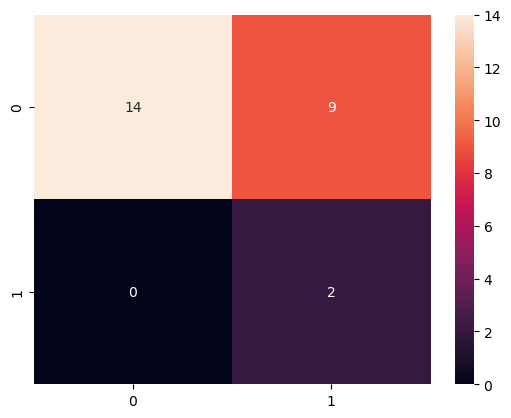

In [46]:
clf_cm = confusion_matrix(y_test,clf_preds)
print(clf_cm)
sns.heatmap(clf_cm, annot=True)

In [47]:
print(classification_report(y_test,clf_preds))

              precision    recall  f1-score   support

           0       1.00      0.61      0.76        23
           1       0.18      1.00      0.31         2

    accuracy                           0.64        25
   macro avg       0.59      0.80      0.53        25
weighted avg       0.93      0.64      0.72        25



## What are recall, and precision ?

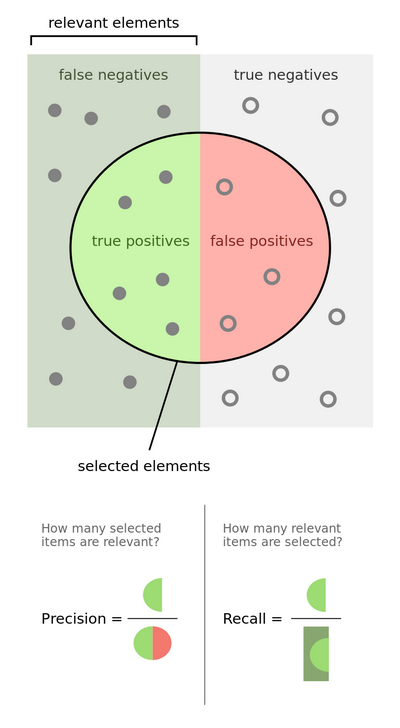

For classification tasks, the terms true positives, true negatives, false positives, and false negatives (see Type I and type II errors for definitions) compare the results of the classifier under test with trusted external judgments. The terms positive and negative refer to the classifier's prediction (sometimes known as the expectation), and the terms true and false refer to whether that prediction corresponds to the external judgment (sometimes known as the observation).

Let us define an experiment from P positive instances and N negative instances for some condition. The four outcomes can be formulated in a 2×2 contingency table or confusion matrix, as follows:
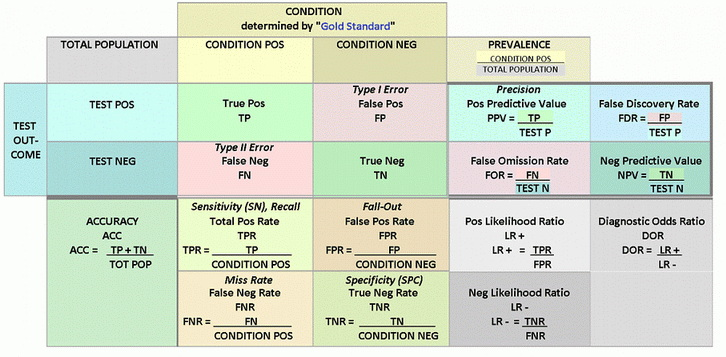


Precision and recall are then defined as:[14]

$$ 
{\begin{aligned}{\text{Precision}}&={\frac {tp}{tp+fp}}\\{\text{Recall}}&={\frac {tp}{tp+fn}}\,\end{aligned}}
$$

Recall in this context is also referred to as the true positive rate or sensitivity, and precision is also referred to as positive predictive value (PPV); other related measures used in classification include true negative rate and accuracy.[14] True negative rate is also called specificity.

$${\text{True negative rate}}={\frac {tn}{tn+fp}}\,$$

## What is f1-score?

The traditional F-measure or balanced F-score (F1 score) is the harmonic mean of precision and recall:
$$
F_1 = 2 \cdot \frac{precision \cdot recall}{precision + recall} = \frac{tp}{tp+\frac{1}{2}(fp+fn)}
$$

A more general F score, $\displaystyle F_{\beta}$, that uses a positive real factor $\beta$, where $\beta$ is chosen such that recall is considered $\beta$ times as important as precision, is:

$$F_\beta = (1 + \beta^2) \cdot \frac{\mathrm{precision} \cdot \mathrm{recall}}{(\beta^2 \cdot \mathrm{precision}) + \mathrm{recall}}.$$

In terms of Type I and type II errors this becomes:



$$F_\beta = \frac {(1 + \beta^2) \cdot \mathrm{true\ positive} }{(1 + \beta^2) \cdot \mathrm{true\ positive} + \beta^2 \cdot \mathrm{false\ negative} + \mathrm{false\ positive}}\,
$$

Two commonly used values for $\beta$ are $2$, which weighs recall higher than precision, and $0.5$, which weighs recall lower than precision.

The F-measure was derived so that $F_{\beta }$ "measures the effectiveness of retrieval with respect to a user who attaches β times as much importance to recall as precision".[2] It is based on Van Rijsbergen's effectiveness measure

$$ 
E=1-\left({\frac {\alpha }{p}}+{\frac {1-\alpha }{r}}\right)^{-1}
$$
Their relationship is $F_{\beta }=1-E$ where $\alpha ={\frac {1}{1+\beta ^{2}}}$.